In [1]:
import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from helpers.SimulationAnalysis import SimulationAnalysis, readHlist, a2z
import pandas as pd
from matplotlib import colormaps
import matplotlib.colors as mcolors
import scipy
import sklearn
from scipy import stats
import pandas as pd

ModuleNotFoundError: No module named 'helpers.SimulationAnalysis'

1 SymphonyLMC
2 SymphonyMilkyWay
3 SymphonyGroup
4 SymphonyLCluster
5 SymphonyCluster


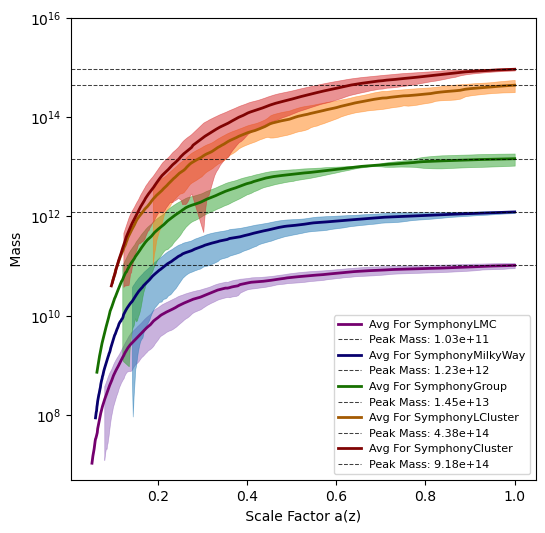

In [117]:
import pandas as pd
import math

base_dir = "C://Users/steph/MWest_data"
#suite_list = ["SymphonyLMC"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]

fig, ax = plt.subplots(figsize = (6, 6))
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]
avg_colors = [(102/225, 0/255, 110/255), (7/255, 0/255, 110/255), (22/255, 112/255, 0/255), (163/255, 90/255, 2/255), (128/255, 3/255, 3/255)]

for index, suite in enumerate(suite_list):
    print(index + 1, suite)
    
    n_hosts = symlib.n_hosts(suite)
    #n_hosts = 20

    masses_suite = np.zeros(n_hosts, dtype = 'object')

    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        h, hist = symlib.read_subhalos(sim_dir)
        scale_factors = symlib.scale_factors(sim_dir)

        params = symlib.simulation_parameters(sim_dir)
        particle_mass = params["mp"]
        
        host_mass = np.array(h["mvir"][0])
        num_particles = host_mass / particle_mass

        mass_cut = 300 * particle_mass
        
        host_mass_masked = np.where(host_mass < mass_cut, np.nan, host_mass)
        #ax.plot(scale_factors, host_mass_masked, color = colors[index], lw = 0.75, alpha = 0.33)
        masses_suite[i_host] = host_mass
    
    vstacked_masses = np.vstack(masses_suite)
    avg_masses = np.nanmean(vstacked_masses, axis = 0)

######################################################################################## (everything above this line appears to be working correctly)

    std_dev = np.nanstd(vstacked_masses, axis = 0)

    mask1 = avg_masses > mass_cut
    mask2 = (avg_masses - std_dev) > mass_cut

    ax.plot(scale_factors[mask1], avg_masses[mask1], color = avg_colors[index], lw = 2, label = f"Avg For {suite}")
    ax.fill_between(scale_factors[mask2], (avg_masses + std_dev)[mask2], (avg_masses - std_dev)[mask2], color = colors[index], alpha = 0.5, lw = 0.5)

    ax.axhline(y = avg_masses[-1], color = "black", linestyle = '--', lw = 0.75, alpha = 0.75, label = f"Peak Mass: {(avg_masses[-1]):.2e}")
    #ax.axvline(x = scale_factors[0], color = "black", linestyle = '--', lw = 0.8, alpha = 0.9, label = f"First Scale Factor: {scale_factors[0]:.2f}")
    ax.set_yscale("log")
    ax.set_xlabel(r" Scale Factor a(z) ", fontsize = 10)
    ax.set_ylabel(r" Mass ", fontsize = 10)
    #ax.set_ylim(1e2 * particle_mass, 1e8 * particle_mass)
    ax.set_ylim(5e6, 1e16)
    ax.legend(loc = 'best', fontsize = 8)
    #ax[index].set_title(f"{suite} > 300x Particle Mass", loc = "center", fontsize = 8)

#fig.suptitle("Total and Average Mass Accretion Histories Of All Suites", fontsize = 13, y = 0.95)
plt.show()

## all the calculations are correct, it's plotting that's weird
## figure out how to do the standard deviations (filtering or otherwise)
## the values are working, it's symmetrical in normal scaling, but when going to log scaling smaller values get distorted
## the difference between the average and the standard deviation is negative at some snapshots is because there is a high variance in masses, and
## the average mass isn't very large at this time.